# RQ1_refined


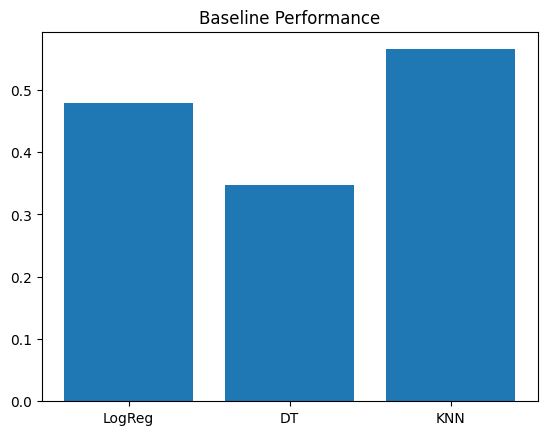

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

df = pd.read_csv('/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv')
df = df.dropna()

X = df.drop('accident_severity', axis=1)
y = df['accident_severity']

X = pd.get_dummies(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

models = {
"LogReg": Pipeline([("scaler",StandardScaler()),("model",LogisticRegression(max_iter=1000))]),
"DT": DecisionTreeClassifier(),
"KNN": Pipeline([("scaler",StandardScaler()),("model",KNeighborsClassifier())])
}

rows=[]
for name,m in models.items():
    m.fit(X_train,y_train)
    pred=m.predict(X_test)
    rows.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred,average='weighted'),
        recall_score(y_test,pred,average='weighted'),
        f1_score(y_test,pred,average='weighted')
    ])

df_res=pd.DataFrame(rows,columns=["Model","Accuracy","Precision","Recall","F1"])
df_res.to_csv("RQ1_table.csv",index=False)

plt.figure()
plt.bar(df_res["Model"],df_res["Accuracy"])
plt.title("Baseline Performance")
plt.savefig("RQ1_figure.pdf")
